I am retrying to write my multiple parrallel interfaces matrix code. Updates needed. Replace for loop to make faster. Make code more flexible for adding interfaces. Make fewer redundant calculations. 

interactive(children=(FloatSlider(value=1.0, description='n0', max=5.0), FloatSlider(value=1.4, description='n…

Runtime: 1.053013 seconds


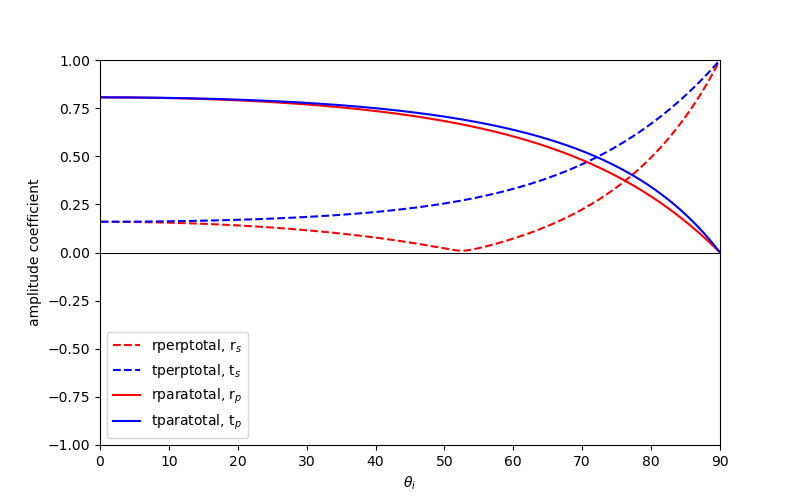

In [1]:
%matplotlib widget

import time
start = time.time()

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd    

# 1 plotting function 

def totalFresnalcoeffPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    th0 = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperptotal, r$_s$', r'tperptotal, t$_s$', r'rparatotal, r$_p$', r'tparatotal, t$_p$'],)
    def plot(n0=1, n1=1.4, n2=1.5, k0=0, k1=0, k2=0, d=1, Wavelength=4):
        output1 = func1(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output2 = func2(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output3 = func3(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output4 = func4(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        line01.set_data(th0, output1)
        line02.set_data(th0, output2)
        line03.set_data(th0, output3)
        line04.set_data(th0, output4)
        plt.draw()
    interact(plot, n0=(0,5,.1), n1=(0,5,.1), n2=(0,5,.1), k0=(0,5,.1), k1=(0,5,.1), k2=(0,5,.1), d=(0,5,.1), Wavelength=(0,5,.1)) 

# 2 Cosine and angle functions 

def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

# 4 General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 

def t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

# 5 General form of fresnel coefficients for p polarized light (parrallel electric field)  

def r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#transmission matrix 

def D_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  

def D_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  


# propagation matrix wich is independant of polarazation

def P(ni, nt, ki, kt, thi, d, Wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength),0],[0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength)]]))



# 6 total fresnel coefficints s polarized

def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11) 


def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   

def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 

def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)   

def mag_r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_p_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])


totalFresnalcoeffPlot(mag_r_p_tot, mag_r_s_tot, mag_t_s_tot, mag_t_p_tot) 

end = time.time()

print(f"Runtime: {end - start:.6f} seconds")
